# Renewables in Electricity Markets: Stakeholder Perspective

Consider a price-taking wind farm with an installed capacity of 500 MW. The objective is to formulate and solve an optimization problem to determine its optimal offering strategy in terms of production quantity in the day-ahead market. The offer price is assumed to be zero. The analysis spans a 24-hour period, focusing exclusively on the day-ahead and balancing markets while excluding the reserve and intra-day markets.

Sources of Uncertainty: For each hour of the following day, the analysis considers the following three sources of uncertainty:
1. Wind power production (obtained from Fingrid - "Wind power generation forecast - updated hourly", September 2025 data)
2. Day-ahead market price (obtained from Energinet, DK2 spot prices, September 2025 data)
3. The real-time power system condition (whether the system experiences a supply deficit or excess).

Scenarios will be generated to model these uncertainties, assuming no correlation among the sources. Historical data can be utilized for scenario generation, where each realization from a past day can be considered as a separate scenario.

## Scenario Generation for Wind Power Production Forecast

In [18]:
from pathlib import Path
import pandas as pd

# Resolve paths relative to the notebook directory
notebook_dir = Path.cwd()
wind_path = notebook_dir / "inputs" / "wind_forecast_reference.xlsx"

# Load wind power generation forecast (15-min resolution)
wind_df = pd.read_excel(wind_path, sheet_name="Data")

# Parse timestamps and tidy column names
wind_df["startTime"] = pd.to_datetime(wind_df["startTime"], utc=True)
wind_df["endTime"] = pd.to_datetime(wind_df["endTime"], utc=True)
wind_df = wind_df.rename(
    columns={
        "Wind power generation forecast - updated every 15 minutes": "wind_forecast_MW"
    }
)

# Scale Fingrid system forecast to the 500 MW wind farm
# (preserve capacity factor: P_farm = P_ref / P_ref_max * P_n)
P_n = 500.0  # MW
P_ref_max = wind_df["wind_forecast_MW"].max()
wind_df["wind_forecast_MW"] = wind_df["wind_forecast_MW"] / P_ref_max * P_n

print(f"Scaled to {P_n:.0f} MW farm (reference max was {P_ref_max:.1f} MW)")
print(
    f"Farm forecast range: "
    f"{wind_df['wind_forecast_MW'].min():.2f} – {wind_df['wind_forecast_MW'].max():.2f} MW"
)
wind_df.head()

Scaled to 500 MW farm (reference max was 7623.1 MW)
Farm forecast range: 0.39 – 500.00 MW


,startTime,endTime,wind_forecast_MW
0,2025-08-31 22:00:00+00:00,2025-08-31 22:15:00+00:00,18.889953
1,2025-08-31 22:15:00+00:00,2025-08-31 22:30:00+00:00,19.047369
2,2025-08-31 22:30:00+00:00,2025-08-31 22:45:00+00:00,19.198226
3,2025-08-31 22:45:00+00:00,2025-08-31 23:00:00+00:00,19.355643
4,2025-08-31 23:00:00+00:00,2025-08-31 23:15:00+00:00,20.542824


In [19]:
# Keep [01.09 00:00, 21.09 00:00) in UTC
start = pd.Timestamp("2025-09-01 00:00", tz="UTC")
end = pd.Timestamp("2025-09-21 00:00", tz="UTC")

wind_15min = wind_df.loc[
    (wind_df["startTime"] >= start) & (wind_df["startTime"] < end),
    ["startTime", "wind_forecast_MW"],
].set_index("startTime").sort_index()

# Aggregate 15-min values to hourly means
wind_hourly = (
    wind_15min["wind_forecast_MW"]
    .resample("h")
    .mean()
    .to_frame(name="wind_forecast_MW")
)

# Verify 20 complete days (each day must have all 24 hours, no missing values)
n_hours = len(wind_hourly)
n_days = n_hours / 24
hours_per_day = wind_hourly.groupby(wind_hourly.index.date).size()
complete_days = (hours_per_day == 24) & (
    wind_hourly.groupby(wind_hourly.index.date)["wind_forecast_MW"].apply(
        lambda s: s.notna().all()
    )
)
n_complete_days = int(complete_days.sum())

print(f"Complete days: {n_complete_days}")
assert n_complete_days == 20, f"Expected 20 complete days, found {n_complete_days}"
assert n_hours == 20 * 24, f"Expected {20 * 24} hourly rows, found {n_hours}"
assert wind_hourly["wind_forecast_MW"].isna().sum() == 0, "Missing hourly values"

wind_hourly.head()

Complete days: 20


,wind_forecast_MW
startTime,
2025-09-01 00:00:00+00:00,23.655075
2025-09-01 01:00:00+00:00,23.061484
2025-09-01 02:00:00+00:00,23.525534
2025-09-01 03:00:00+00:00,21.697210
2025-09-01 04:00:00+00:00,22.726975


In [20]:
wind_hourly.tail()

,wind_forecast_MW
startTime,
2025-09-20 19:00:00+00:00,89.505910
2025-09-20 20:00:00+00:00,75.484383
2025-09-20 21:00:00+00:00,84.086526
2025-09-20 22:00:00+00:00,65.554040
2025-09-20 23:00:00+00:00,58.011177


In [21]:
# Build 20 wind scenarios for day 20.09:
# each historical day (01.09–20.09) is one equally likely scenario,
# aligned by hour of day (UTC) so all scenarios span the same 24 hours.
target_day = pd.Timestamp("2025-09-20", tz="UTC").date()

wind_scen = wind_hourly.copy()
wind_scen["date"] = wind_scen.index.date
wind_scen["hour"] = wind_scen.index.hour

wind_scenarios = (
    wind_scen.pivot(index="hour", columns="date", values="wind_forecast_MW")
    .sort_index(axis=0)
    .sort_index(axis=1)
)

# Label scenarios ω1…ω20 (historical day kept in the column MultiIndex for traceability)
historical_days = list(wind_scenarios.columns)
wind_scenarios.columns = pd.MultiIndex.from_arrays(
    [
        [f"ω{i}" for i in range(1, len(historical_days) + 1)],
        historical_days,
    ],
    names=["scenario", "historical_day"],
)

# Equal probability for each historical realization
p_wind = pd.Series(
    1.0 / len(historical_days),
    index=wind_scenarios.columns.get_level_values("scenario"),
    name="probability",
)

# Verify: 20 complete scenarios, same hours (0–23), no missing values
n_scenarios = wind_scenarios.shape[1]
hours = wind_scenarios.index.to_list()

print(f"Target day: {target_day}")
print(f"Number of scenarios: {n_scenarios}")
print(f"Hours per scenario: {len(hours)} → {hours[0]:02d}:00–{hours[-1]:02d}:00 UTC")
print(f"Missing values: {int(wind_scenarios.isna().sum().sum())}")

assert n_scenarios == 20, f"Expected 20 scenarios, found {n_scenarios}"
assert hours == list(range(24)), f"Expected hours 0–23, found {hours}"
assert wind_scenarios.isna().sum().sum() == 0, "Incomplete scenario(s): missing values"
assert (wind_scenarios.notna().sum(axis=0) == 24).all(), "Not all scenarios span 24 hours"

wind_scenarios

Target day: 2025-09-20
Number of scenarios: 20
Hours per scenario: 24 → 00:00–23:00 UTC
Missing values: 0


scenario,ω1,ω2,ω3,ω4,ω5,ω6,ω7,ω8,ω9,ω10,ω11,ω12,ω13,ω14,ω15,ω16,ω17,ω18,ω19,ω20
historical_day,2025-09-01,2025-09-02,2025-09-03,2025-09-04,2025-09-05,2025-09-06,2025-09-07,2025-09-08,2025-09-09,2025-09-10,2025-09-11,2025-09-12,2025-09-13,2025-09-14,2025-09-15,2025-09-16,2025-09-17,2025-09-18,2025-09-19,2025-09-20
hour,,,,,,,,,,,,,,,,,,,,
0,23.655075,73.192009,154.681166,198.429773,176.457084,187.717267,137.955687,97.142239,43.750246,122.141911,266.082696,310.938135,249.980323,247.364917,142.346945,288.381695,194.779683,127.402238,18.393108,143.952264
1,23.061484,70.511013,144.926277,201.758471,194.586192,197.659089,143.029083,79.003293,46.354173,110.903045,280.118980,310.990607,242.034081,229.002965,167.379413,306.422256,185.511800,138.913303,17.565033,178.880639
2,23.525534,82.641904,152.975823,198.005077,200.643439,179.915323,135.883040,70.624156,48.269405,109.509255,285.758091,314.096299,241.450329,214.437040,207.592712,312.235180,177.831197,143.496412,16.153205,199.879314
3,21.697210,99.252601,158.457517,193.320303,222.327531,169.966943,130.222613,69.186092,45.201427,103.320827,298.453057,371.318755,236.419567,193.451483,247.314085,320.532329,159.479083,131.144154,15.807218,202.709528
4,22.726975,108.372906,170.957353,182.804568,203.062074,152.554407,124.453962,64.440648,41.300455,94.572746,304.702155,374.685167,223.836103,166.880928,283.631331,325.690992,144.209705,118.475423,17.417455,213.636841
5,22.849956,111.593381,180.851622,155.929018,176.312786,130.186538,95.902586,58.235823,40.898716,94.125093,309.408246,383.210243,210.988640,141.353255,306.660020,332.469730,129.173171,107.938372,18.260288,233.858273
6,20.670725,88.112120,174.717307,133.515237,131.045769,83.183023,74.548084,53.434626,35.897470,77.152012,299.313927,380.179979,192.536501,105.052407,335.696764,328.770448,111.883617,95.845194,18.232412,255.339035
7,17.489604,74.682544,164.093348,145.091892,105.614842,46.085254,67.780824,48.298920,30.910981,54.065931,235.714473,381.665595,169.914470,83.510973,356.856135,331.259593,87.300442,80.736511,15.905603,233.423738


### Wind power generation distribution plot

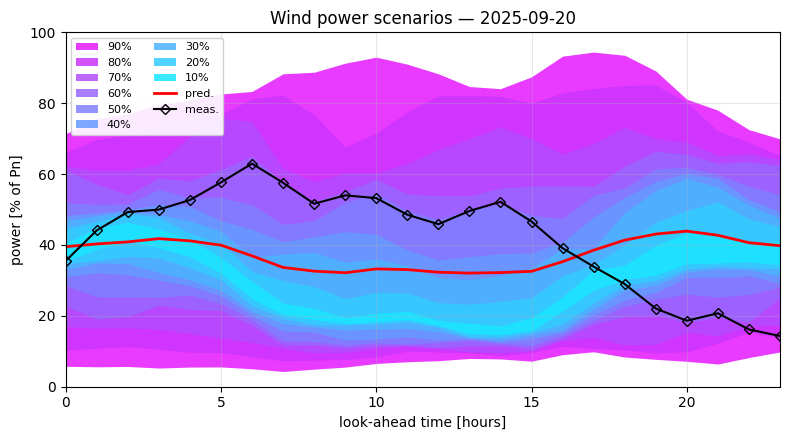

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- inputs from your scenario cell ---
# wind_scenarios: index = hour 0..23, columns = ω1..ω20
hours = wind_scenarios.index.to_numpy()
scen = wind_scenarios.to_numpy()  # shape (24, 20)

# Nominal power for % axis (match figure style).
# Option A: scale relative to max in the scenario set
P_n = scen.max()
# Option B (after scaling Fingrid → 500 MW farm): P_n = 500.0

power_pct = scen / P_n * 100.0

# "pred." = scenario mean; "meas." = realized day 20.09 (last historical day)
pred = power_pct.mean(axis=1)
meas_col = [c for c in wind_scenarios.columns if c[1] == target_day][0]
meas = wind_scenarios[meas_col].to_numpy() / P_n * 100.0

# Central prediction intervals: 10%, 20%, ..., 90%
# → lower/upper percentiles (5,95), (10,90), ..., (45,55)
intervals = list(range(10, 100, 10))  # 10..90
cmap = plt.cm.cool  # purple → light blue, similar to the figure

fig, ax = plt.subplots(figsize=(8, 4.5))

# Draw outer bands first so the innermost stays on top / darkest
for width in sorted(intervals, reverse=True):
    alpha = (100 - width) / 2  # e.g. 90% → 5th/95th; 10% → 45th/55th
    lo = np.percentile(power_pct, alpha, axis=1)
    hi = np.percentile(power_pct, 100 - alpha, axis=1)
    color = cmap(width / 100.0)
    ax.fill_between(
        hours, lo, hi,
        color=color, alpha=0.85, linewidth=0,
        label=f"{width}%",
    )

ax.plot(hours, pred, color="red", lw=2, label="pred.")
ax.plot(
    hours, meas,
    color="black", lw=1.5, marker="D", ms=5,
    markerfacecolor="none", label="meas.",
)

ax.set_xlabel("look-ahead time [hours]")
ax.set_ylabel("power [% of Pn]")
ax.set_xlim(hours.min(), hours.max())
ax.set_ylim(0, 100)
ax.set_title("Wind power scenarios — 2025-09-20")
ax.grid(True, alpha=0.3)

# Legend: intervals + pred/meas (like the reference figure)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper left", fontsize=8, framealpha=0.9, ncol=2)

plt.tight_layout()
plt.show()

## Scenario Generation for Day-Ahead Price Forecast

In [23]:
price_path = notebook_dir / "inputs" / "day_ahead_prices.xlsx"

# Load DK2 day-ahead prices (already hourly) and convert DKK → EUR
# Official Danmarks Nationalbank central rate (ERM II peg)
DKK_PER_EUR = 7.46038

price_df = pd.read_excel(price_path, sheet_name="data")
price_df["HourUTC"] = pd.to_datetime(price_df["HourUTC"], utc=True)
price_df["DA_price_EUR_MWh"] = price_df["DK2_DKK/MWh"] / DKK_PER_EUR

price_df[["HourUTC", "DK2_DKK/MWh", "DA_price_EUR_MWh"]].head()

,HourUTC,DK2_DKK/MWh,DA_price_EUR_MWh
0,2025-08-31 22:00:00+00:00,627.191510,84.069647
1,2025-08-31 23:00:00+00:00,607.785377,81.468421
2,2025-09-01 00:00:00+00:00,600.918604,80.547989
3,2025-09-01 01:00:00+00:00,581.437825,77.936757
4,2025-09-01 02:00:00+00:00,595.096769,79.767622


In [24]:
# Keep [01.09 00:00, 21.09 00:00) in UTC (already hourly — no resampling)
start = pd.Timestamp("2025-09-01 00:00", tz="UTC")
end = pd.Timestamp("2025-09-21 00:00", tz="UTC")

price_hourly = (
    price_df.loc[
        (price_df["HourUTC"] >= start) & (price_df["HourUTC"] < end),
        ["HourUTC", "DA_price_EUR_MWh"],
    ]
    .set_index("HourUTC")
    .sort_index()
)

# Verify 20 complete days
n_hours = len(price_hourly)
hours_per_day = price_hourly.groupby(price_hourly.index.date).size()
complete_days = (hours_per_day == 24) & (
    price_hourly.groupby(price_hourly.index.date)["DA_price_EUR_MWh"].apply(
        lambda s: s.notna().all()
    )
)
n_complete_days = int(complete_days.sum())

print(f"Complete days: {n_complete_days}")
assert n_complete_days == 20, f"Expected 20 complete days, found {n_complete_days}"
assert n_hours == 20 * 24, f"Expected {20 * 24} hourly rows, found {n_hours}"
assert price_hourly["DA_price_EUR_MWh"].isna().sum() == 0, "Missing hourly values"

price_hourly.head()

Complete days: 20


,DA_price_EUR_MWh
HourUTC,
2025-09-01 00:00:00+00:00,80.547989
2025-09-01 01:00:00+00:00,77.936757
2025-09-01 02:00:00+00:00,79.767622
2025-09-01 03:00:00+00:00,88.461717
2025-09-01 04:00:00+00:00,117.765538


In [25]:
# Build 20 day-ahead price scenarios for day 20.09:
# each historical day (01.09–20.09) is one equally likely scenario,
# aligned by hour of day (UTC) so all scenarios span the same 24 hours.
target_day = pd.Timestamp("2025-09-20", tz="UTC").date()

price_scen = price_hourly.copy()
price_scen["date"] = price_scen.index.date
price_scen["hour"] = price_scen.index.hour

price_scenarios = (
    price_scen.pivot(index="hour", columns="date", values="DA_price_EUR_MWh")
    .sort_index(axis=0)
    .sort_index(axis=1)
)

historical_days = list(price_scenarios.columns)
price_scenarios.columns = pd.MultiIndex.from_arrays(
    [
        [f"ω{i}" for i in range(1, len(historical_days) + 1)],
        historical_days,
    ],
    names=["scenario", "historical_day"],
)

p_price = pd.Series(
    1.0 / len(historical_days),
    index=price_scenarios.columns.get_level_values("scenario"),
    name="probability",
)

n_scenarios = price_scenarios.shape[1]
hours = price_scenarios.index.to_list()

print(f"Target day: {target_day}")
print(f"Number of scenarios: {n_scenarios}")
print(f"Hours per scenario: {len(hours)} → {hours[0]:02d}:00–{hours[-1]:02d}:00 UTC")
print(f"Missing values: {int(price_scenarios.isna().sum().sum())}")

assert n_scenarios == 20, f"Expected 20 scenarios, found {n_scenarios}"
assert hours == list(range(24)), f"Expected hours 0–23, found {hours}"
assert price_scenarios.isna().sum().sum() == 0, "Incomplete scenario(s): missing values"
assert (price_scenarios.notna().sum(axis=0) == 24).all(), "Not all scenarios span 24 hours"

price_scenarios

Target day: 2025-09-20
Number of scenarios: 20
Hours per scenario: 24 → 00:00–23:00 UTC
Missing values: 0


scenario,ω1,ω2,ω3,ω4,ω5,ω6,ω7,ω8,ω9,ω10,ω11,ω12,ω13,ω14,ω15,ω16,ω17,ω18,ω19,ω20
historical_day,2025-09-01,2025-09-02,2025-09-03,2025-09-04,2025-09-05,2025-09-06,2025-09-07,2025-09-08,2025-09-09,2025-09-10,2025-09-11,2025-09-12,2025-09-13,2025-09-14,2025-09-15,2025-09-16,2025-09-17,2025-09-18,2025-09-19,2025-09-20
hour,,,,,,,,,,,,,,,,,,,,
0,80.547989,90.874333,85.983638,14.918034,85.290500,99.578959,80.737808,84.723779,110.407542,98.362195,76.967329,20.581084,72.308939,80.483347,4.582591,0.050031,47.965189,34.920211,70.409431,74.751250
1,77.936757,92.544970,81.771991,19.790659,85.250475,97.827922,83.359356,82.291948,109.867112,99.032617,70.494188,15.948589,72.268924,85.796206,3.101754,0.070043,45.603952,32.578855,70.549489,74.561168
2,79.767622,94.835837,81.281801,24.233050,85.650713,96.937395,82.879076,72.504575,110.047255,99.983215,70.534209,14.797970,69.627494,93.620420,2.111194,0.370229,51.026798,40.063186,70.929653,74.561168
3,88.461717,106.860378,87.034052,60.532600,97.387666,97.968012,80.327562,74.996455,118.243757,107.588022,78.958292,13.537291,72.599097,99.663675,2.141211,2.151331,69.276380,56.982978,86.726257,79.953421
4,117.765538,134.480807,103.280406,73.069351,119.210585,97.827922,77.996180,125.124186,182.514710,133.424357,111.043854,31.336877,74.560152,100.634199,19.260889,3.932434,93.088888,101.918984,113.627502,88.236883
5,128.440578,153.738084,112.734109,96.832149,132.188271,105.382398,44.406294,160.650928,302.059509,223.541334,125.210729,96.962224,74.029867,105.256684,54.360734,17.070564,112.178916,114.386198,143.109828,86.806285
6,116.154777,147.555755,109.222733,103.585786,125.814494,91.454153,11.106576,129.567532,197.136305,172.068802,120.318356,87.527141,72.388984,108.478420,40.462874,21.393239,109.317412,109.673472,117.349059,74.991348
7,98.236331,121.115764,84.012873,77.861933,100.459485,56.183269,6.854058,102.587224,127.701252,129.551913,101.349157,44.443934,46.364970,87.817292,4.692653,12.627815,90.047290,88.961488,95.119765,24.560266


### Day-Ahead prices distribution plot

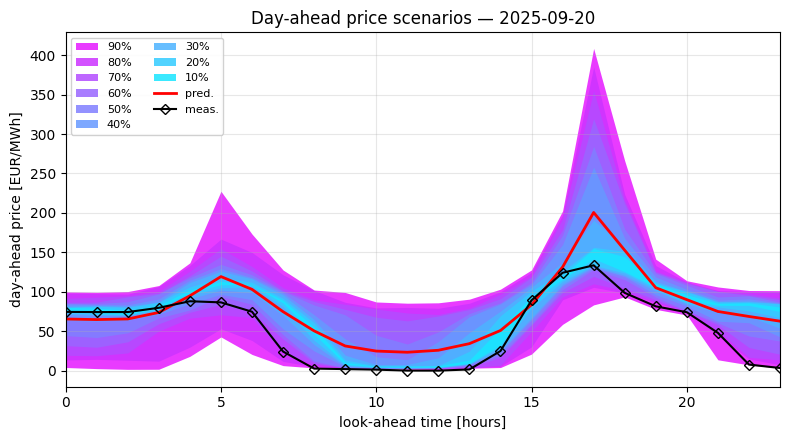

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# price_scenarios: index = hour 0..23, columns = ω1..ω20 [EUR/MWh]
hours = price_scenarios.index.to_numpy()
scen = price_scenarios.to_numpy()  # shape (24, 20)

# "pred." = scenario mean; "meas." = realized day 20.09
pred = scen.mean(axis=1)
meas_col = [c for c in price_scenarios.columns if c[1] == target_day][0]
meas = price_scenarios[meas_col].to_numpy()

# Central prediction intervals: 10%, 20%, ..., 90%
intervals = list(range(10, 100, 10))
cmap = plt.cm.cool

fig, ax = plt.subplots(figsize=(8, 4.5))

for width in sorted(intervals, reverse=True):
    alpha = (100 - width) / 2  # 90% → 5/95; 10% → 45/55
    lo = np.percentile(scen, alpha, axis=1)
    hi = np.percentile(scen, 100 - alpha, axis=1)
    ax.fill_between(
        hours, lo, hi,
        color=cmap(width / 100.0), alpha=0.85, linewidth=0,
        label=f"{width}%",
    )

ax.plot(hours, pred, color="red", lw=2, label="pred.")
ax.plot(
    hours, meas,
    color="black", lw=1.5, marker="D", ms=5,
    markerfacecolor="none", label="meas.",
)

ax.set_xlabel("look-ahead time [hours]")
ax.set_ylabel("day-ahead price [EUR/MWh]")
ax.set_xlim(hours.min(), hours.max())
ax.set_title("Day-ahead price scenarios — 2025-09-20")
ax.grid(True, alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper left", fontsize=8, framealpha=0.9, ncol=2)

plt.tight_layout()
plt.show()

## Scenario Generation for Real-Time Power System Condition - no forecast

To model the power system condition, 24 random binary (two-state) variables are generated, each representing whether the system experiences a power supply **deficit** (`1`) or **excess** (`0`) in a given hour. Draws are i.i.d. Bernoulli for each hour (and independent across scenarios), consistent with no correlation among uncertainty sources.

In [27]:
import numpy as np

# 4 system-condition scenarios for day 20.09 (same count as wind/price),
# each a 24-hour binary profile: 1 = supply deficit, 0 = supply excess
n_system_scenarios = 4
hours = list(range(24))
p_deficit = 0.5  # P(deficit) per hour; P(excess) = 1 - p_deficit
rng = np.random.default_rng(seed=42)  # fixed seed for reproducibility

system_draws = rng.binomial(n=1, p=p_deficit, size=(len(hours), n_system_scenarios))

system_scenarios = pd.DataFrame(
    system_draws,
    index=pd.Index(hours, name="hour"),
    columns=pd.MultiIndex.from_arrays(
        [
            [f"ω{i}" for i in range(1, n_system_scenarios + 1)],
            ["Bernoulli"] * n_system_scenarios,
        ],
        names=["scenario", "source"],
    ),
)

p_system = pd.Series(
    1.0 / n_system_scenarios,
    index=system_scenarios.columns.get_level_values("scenario"),
    name="probability",
)

# Verify: 20 complete scenarios spanning the same 24 hours, binary-valued
n_scenarios = system_scenarios.shape[1]
unique_vals = set(np.unique(system_scenarios.to_numpy()))

print(f"Number of scenarios: {n_scenarios}")
print(f"Hours per scenario: {len(system_scenarios.index)} → 00:00–23:00")
print(f"Unique values: {sorted(unique_vals)}  (1=deficit, 0=excess)")
print(f"Empirical P(deficit): {system_scenarios.to_numpy().mean():.3f}")

assert n_scenarios == 4, f"Expected 4 scenarios, found {n_scenarios}"
assert system_scenarios.index.to_list() == list(range(24)), "Hours must be 0–23"
assert system_scenarios.isna().sum().sum() == 0, "Incomplete scenario(s): missing values"
assert (system_scenarios.notna().sum(axis=0) == 24).all(), "Not all scenarios span 24 hours"
assert unique_vals <= {0, 1}, f"Non-binary values found: {unique_vals}"

system_scenarios

Number of scenarios: 4
Hours per scenario: 24 → 00:00–23:00
Unique values: [np.int64(0), np.int64(1)]  (1=deficit, 0=excess)
Empirical P(deficit): 0.479


scenario,ω1,ω2,ω3,ω4
source,Bernoulli,Bernoulli,Bernoulli,Bernoulli
hour,,,,
0,1,0,1,1
1,0,1,1,1
2,0,0,0,1
3,1,1,0,0
4,1,0,1,1
5,1,0,1,1
6,1,0,0,0
7,0,1,1,1


## Final Scenarios

In [28]:
import numpy as np
import pandas as pd

# --- scenario counts (Cartesian product; independent uncertainties) ---
n_wind = wind_scenarios.shape[1]
n_price = price_scenarios.shape[1]
n_system = system_scenarios.shape[1]

n_total = n_wind * n_price * n_system
print(f"Total scenarios: {n_wind} × {n_price} × {n_system} = {n_total:,}")

# Build full scenario index: every (wind, price, system) combination
wind_ids = wind_scenarios.columns.get_level_values("scenario").tolist()
price_ids = price_scenarios.columns.get_level_values("scenario").tolist()
system_ids = system_scenarios.columns.get_level_values("scenario").tolist()

full_index = pd.MultiIndex.from_product(
    [wind_ids, price_ids, system_ids],
    names=["wind", "price", "system"],
)

# Equal probability if each marginal scenario is equally likely and independent
p_joint = 1.0 / n_total

# --- in-sample / out-of-sample split ---
n_in_sample = 200          # at least 200 for decision-making
assert n_in_sample >= 200
assert n_in_sample < n_total, "Need remaining scenarios for out-of-sample analysis"

rng = np.random.default_rng(seed=123)
perm = rng.permutation(n_total)

in_sample_idx = full_index[perm[:n_in_sample]]
out_sample_idx = full_index[perm[n_in_sample:]]

print(f"In-sample:      {len(in_sample_idx):,}  (for optimization / decision-making)")
print(f"Out-of-sample:  {len(out_sample_idx):,}  (for ex-post evaluation)")

# Optional: look up trajectories for one joint scenario
def get_joint_scenario(wind_id, price_id, system_id):
    return {
        "wind_MW": wind_scenarios.xs(wind_id, axis=1, level="scenario").iloc[:, 0],
        "price_EUR_MWh": price_scenarios.xs(price_id, axis=1, level="price" if False else "scenario").iloc[:, 0],
        "system": system_scenarios.xs(system_id, axis=1, level="scenario").iloc[:, 0],
        "probability": p_joint,
    }

# Re-normalize in-sample probabilities for the optimization (equiprobable subset)
p_in_sample = pd.Series(
    1.0 / len(in_sample_idx),
    index=in_sample_idx,
    name="probability",
)

Total scenarios: 20 × 20 × 4 = 1,600
In-sample:      200  (for optimization / decision-making)
Out-of-sample:  1,400  (for ex-post evaluation)


## Balancing Price Forecasts

In [29]:
# Balancing price from DA price × coefficient given system condition
# deficit (1) → 1.25 × λ^DA ; excess (0) → 0.85 × λ^DA

COEF_DEFICIT = 1.25
COEF_EXCESS = 0.85

def balancing_price_for_joint(wind_id, price_id, system_id):
    """Return 24-hour balancing price [EUR/MWh] for one joint scenario."""
    da = price_scenarios.xs(price_id, axis=1, level="scenario").iloc[:, 0]
    sys = system_scenarios.xs(system_id, axis=1, level="scenario").iloc[:, 0]
    # sys is 0/1 per hour → coefficient per hour
    coef = np.where(sys.to_numpy() == 1, COEF_DEFICIT, COEF_EXCESS)
    bal = da.to_numpy() * coef
    return pd.Series(bal, index=da.index, name="balancing_price_EUR_MWh")

# Example: build balancing prices for all in-sample scenarios
# (store as dict keyed by (wind, price, system) for later optimization)
bal_in_sample = {}
for wind_id, price_id, system_id in in_sample_idx:
    bal_in_sample[(wind_id, price_id, system_id)] = balancing_price_for_joint(
        wind_id, price_id, system_id
    )

# Same for out-of-sample (ex-post)
bal_out_sample = {}
for wind_id, price_id, system_id in out_sample_idx:
    bal_out_sample[(wind_id, price_id, system_id)] = balancing_price_for_joint(
        wind_id, price_id, system_id
    )

# Quick check on one scenario
w0, p0, s0 = in_sample_idx[0]
demo = pd.DataFrame({
    "wind": wind_scenarios.xs(w0, axis=1, level="scenario").iloc[:, 0],
    "DA": price_scenarios.xs(p0, axis=1, level="scenario").iloc[:, 0],
    "system": system_scenarios.xs(s0, axis=1, level="scenario").iloc[:, 0],
    "balancing": bal_in_sample[(w0, p0, s0)],
})
demo["coef"] = np.where(demo["system"] == 1, COEF_DEFICIT, COEF_EXCESS)
demo.head(8)

,wind,DA,system,balancing,coef
hour,,,,,
0,18.393108,72.308939,1,90.386174,1.25
1,17.565033,72.268924,0,61.428585,0.85
2,16.153205,69.627494,0,59.183370,0.85
3,15.807218,72.599097,1,90.748871,1.25
4,17.417455,74.560152,1,93.200190,1.25
5,18.260288,74.029867,1,92.537334,1.25
6,18.232412,72.388984,1,90.486229,1.25
7,15.905603,46.364970,0,39.410225,0.85


## Part 1: Optimal offering strategy and risk management

### Offering Strategy Under a One-Price Balancing Scheme

Formulate and solve the stochastic offering strategy problem for a one-price balancing scheme using in-sample scenarios. Determine the optimal hourly production quantity offers of the wind farm in the day-ahead market and calculate the expected profit. Additionally, illustrate the cumulative distribution of profit across the in-sample scenarios.

In [30]:
import pulp

P_nom = 500.0
hours = list(range(24))
Omega = list(in_sample_idx)
pi = 1.0 / len(Omega)

# Lookup tables
p_real = {}
lam_DA = {}
lam_bal = {}
for omega in Omega:
    w_id, p_id, s_id = omega
    p_real[omega] = wind_scenarios.xs(w_id, axis=1, level="scenario").iloc[:, 0]
    da = price_scenarios.xs(p_id, axis=1, level="scenario").iloc[:, 0]
    lam_DA[omega] = da
    lam_bal[omega] = bal_in_sample[omega]

prob = pulp.LpProblem("stochastic_offering_one_price", pulp.LpMaximize)
p_DA = pulp.LpVariable.dicts("p_DA", hours, lowBound=0, upBound=P_nom)
d_up = pulp.LpVariable.dicts("d_up", [(t, w) for t in hours for w in Omega], lowBound=0)
d_dn = pulp.LpVariable.dicts("d_dn", [(t, w) for t in hours for w in Omega], lowBound=0)

prob += pulp.lpSum(
    pi * (
        lam_DA[w].iloc[t] * p_DA[t]
        + lam_bal[w].iloc[t] * d_up[(t, w)]
        - lam_bal[w].iloc[t] * d_dn[(t, w)]
    )
    for t in hours for w in Omega
)

for t in hours:
    for w in Omega:
        prob += p_real[w].iloc[t] - p_DA[t] == d_up[(t, w)] - d_dn[(t, w)]

prob.solve(pulp.PULP_CBC_CMD(msg=False))
print("Status:", pulp.LpStatus[prob.status])
print(f"Expected profit: {pulp.value(prob.objective):.2f} EUR")

opt_offers = pd.Series({t: pulp.value(p_DA[t]) for t in hours}, name="p_DA_MW")
print(opt_offers)

Status: Optimal
Expected profit: 320714.46 EUR
0       0.0
1       0.0
2     500.0
3       0.0
4       0.0
5       0.0
6     500.0
7       0.0
8     500.0
9     500.0
10      0.0
11      0.0
12    500.0
13      0.0
14    500.0
15      0.0
16      0.0
17    500.0
18    500.0
19      0.0
20      0.0
21    500.0
22      0.0
23    500.0
Name: p_DA_MW, dtype: float64


In the one-price balancing scheme, the asset follows a bang-bang bidding strategy, meaning that it optimally bids either zero or its full nominal capacity. This occurs because the expected profit changes linearly with the Day-Ahead offer. If the expected Day-Ahead price is higher than the expected balancing price, every additional MW sold in the Day-Ahead market increases the expected profit, so the optimizer bids the full nominal capacity. Conversely, if the expected balancing price is higher than the expected Day-Ahead price, increasing the Day-Ahead offer reduces the expected profit, so the optimizer bids zero. Since there is no additional penalty or different treatment of positive and negative deviations, there is no economic advantage in selecting an intermediate Day-Ahead offer, which results in the observed bang-bang behavior.

### Offering Strategy Under a Two-Price Balancing Scheme

In [31]:
import pulp
import numpy as np

P_nom = 500.0
hours = list(range(24))
Omega = list(range(len(in_sample_idx)))
pi = 1.0 / len(Omega)

p_real = np.zeros((24, len(Omega)))
lam_DA = np.zeros((24, len(Omega)))
lam_up = np.zeros((24, len(Omega)))
lam_dn = np.zeros((24, len(Omega)))

for w, (w_id, p_id, s_id) in enumerate(in_sample_idx):
    p_real[:, w] = wind_scenarios.xs(w_id, axis=1, level="scenario").iloc[:, 0].to_numpy()
    da = price_scenarios.xs(p_id, axis=1, level="scenario").iloc[:, 0].to_numpy()
    sys = system_scenarios.xs(s_id, axis=1, level="scenario").iloc[:, 0].to_numpy()
    bal = bal_in_sample[(w_id, p_id, s_id)].to_numpy()
    lam_DA[:, w] = da
    # deficit (1): up desired→DA, down undesired→bal
    # excess  (0): up undesired→bal, down desired→DA
    lam_up[:, w] = np.where(sys == 1, da, bal)
    lam_dn[:, w] = np.where(sys == 1, bal, da)

prob = pulp.LpProblem("two_price_offering", pulp.LpMaximize)
p_DA = pulp.LpVariable.dicts("p_DA", hours, lowBound=0, upBound=P_nom)
d_up = pulp.LpVariable.dicts("d_up", [(t, w) for t in hours for w in Omega], lowBound=0, upBound=P_nom)
d_dn = pulp.LpVariable.dicts("d_dn", [(t, w) for t in hours for w in Omega], lowBound=0, upBound=P_nom)
y = pulp.LpVariable.dicts("y", [(t, w) for t in hours for w in Omega], cat="Binary")

prob += pulp.lpSum(
    pi * (lam_DA[t, w] * p_DA[t] + lam_up[t, w] * d_up[(t, w)] - lam_dn[t, w] * d_dn[(t, w)])
    for t in hours for w in Omega
)
for t in hours:
    for w in Omega:
        prob += p_real[t, w] - p_DA[t] == d_up[(t, w)] - d_dn[(t, w)]
        prob += d_up[(t, w)] <= P_nom * y[(t, w)]
        prob += d_dn[(t, w)] <= P_nom * (1 - y[(t, w)])

prob.solve(pulp.PULP_CBC_CMD(msg=False))  # or GUROBI_CMD
print(pulp.LpStatus[prob.status], pulp.value(prob.objective))
opt_offers = pd.Series({t: pulp.value(p_DA[t]) for t in hours}, name="p_DA_MW")
print(opt_offers)

Optimal 267446.6193120049
0      97.142239
1      70.511013
2     200.643440
3     103.320830
4      64.440648
5      58.235823
6     131.045770
7      46.085254
8     371.940220
9     164.093350
10     47.029752
11     47.984088
12     68.349818
13     27.721662
14     62.589367
15     40.190343
16     37.356850
17    392.843790
18    142.753600
19     50.166599
20    128.799310
21    203.639270
22    131.601650
23    196.157080
Name: p_DA_MW, dtype: float64


### Ex-post Analysis

Conduct ex-post cross-validation analyses to evaluate the quality of the offering decisions made in both previous steps. With 200 in-sample and 1,400 out-of-sample scenarios, perform an 8-fold cross-validation analysis. For each run (with the given 200 in-sample and 1,400 out-of-sample scenarios), calculate the expected profits for both the in-sample and out-of-sample analyses. After completing all 8 runs, calculate the average expected profits for both the in-sample and out-of-sample analyses. Considering the results from all 8runs, compare the average expected profits from the in-sample analyses to those from the out-of-sample analyses.

In [32]:
import numpy as np
import pandas as pd
import pulp

P_nom = 500.0
n_folds = 8
n_in = 200
n_total = len(full_index)
assert n_total == n_folds * n_in  # 1600 = 8 × 200
hours = list(range(24))

# --- Precompute data for all joint scenarios ---
p_real_all = np.zeros((24, n_total))
lam_DA_all = np.zeros((24, n_total))
lam_bal_all = np.zeros((24, n_total))
sys_all = np.zeros((24, n_total))

for k, (w_id, p_id, s_id) in enumerate(full_index):
    p_real_all[:, k] = wind_scenarios.xs(w_id, axis=1, level="scenario").iloc[:, 0].to_numpy()
    da = price_scenarios.xs(p_id, axis=1, level="scenario").iloc[:, 0].to_numpy()
    s = system_scenarios.xs(s_id, axis=1, level="scenario").iloc[:, 0].to_numpy()
    lam_DA_all[:, k] = da
    sys_all[:, k] = s
    lam_bal_all[:, k] = da * np.where(s == 1, COEF_DEFICIT, COEF_EXCESS)

lam_up_all = np.where(sys_all == 1, lam_DA_all, lam_bal_all)  # desired→DA, undesired→bal
lam_dn_all = np.where(sys_all == 1, lam_bal_all, lam_DA_all)


def expected_profit(offers, idx, scheme: str) -> float:
    """Expected profit of fixed DA offers on scenario index array `idx`."""
    n = len(idx)
    pi = 1.0 / n
    profit = 0.0
    for t in hours:
        p_da = offers[t]
        for k in idx:
            delta = p_real_all[t, k] - p_da
            if scheme == "one":
                profit += pi * (lam_DA_all[t, k] * p_da + lam_bal_all[t, k] * delta)
            else:
                d_up = max(delta, 0.0)
                d_dn = max(-delta, 0.0)
                profit += pi * (
                    lam_DA_all[t, k] * p_da
                    + lam_up_all[t, k] * d_up
                    - lam_dn_all[t, k] * d_dn
                )
    return profit


def solve_one_price(idx):
    n = len(idx)
    pi = 1.0 / n
    prob = pulp.LpProblem("one_price_cv", pulp.LpMaximize)
    p_DA = pulp.LpVariable.dicts("p_DA", hours, lowBound=0, upBound=P_nom)
    d_up = pulp.LpVariable.dicts("u", [(t, j) for t in hours for j in range(n)], lowBound=0)
    d_dn = pulp.LpVariable.dicts("d", [(t, j) for t in hours for j in range(n)], lowBound=0)

    prob += pulp.lpSum(
        pi * (
            lam_DA_all[t, idx[j]] * p_DA[t]
            + lam_bal_all[t, idx[j]] * d_up[(t, j)]
            - lam_bal_all[t, idx[j]] * d_dn[(t, j)]
        )
        for t in hours for j in range(n)
    )
    for t in hours:
        for j in range(n):
            prob += p_real_all[t, idx[j]] - p_DA[t] == d_up[(t, j)] - d_dn[(t, j)]

    status = prob.solve(pulp.PULP_CBC_CMD(msg=False))
    assert pulp.LpStatus[status] == "Optimal", pulp.LpStatus[status]
    offers = np.array([pulp.value(p_DA[t]) for t in hours])
    return offers


def solve_two_price(idx):
    n = len(idx)
    pi = 1.0 / n
    prob = pulp.LpProblem("two_price_cv", pulp.LpMaximize)
    p_DA = pulp.LpVariable.dicts("p_DA", hours, lowBound=0, upBound=P_nom)
    d_up = pulp.LpVariable.dicts("u", [(t, j) for t in hours for j in range(n)], lowBound=0, upBound=P_nom)
    d_dn = pulp.LpVariable.dicts("d", [(t, j) for t in hours for j in range(n)], lowBound=0, upBound=P_nom)
    y = pulp.LpVariable.dicts("y", [(t, j) for t in hours for j in range(n)], cat="Binary")

    prob += pulp.lpSum(
        pi * (
            lam_DA_all[t, idx[j]] * p_DA[t]
            + lam_up_all[t, idx[j]] * d_up[(t, j)]
            - lam_dn_all[t, idx[j]] * d_dn[(t, j)]
        )
        for t in hours for j in range(n)
    )
    for t in hours:
        for j in range(n):
            prob += p_real_all[t, idx[j]] - p_DA[t] == d_up[(t, j)] - d_dn[(t, j)]
            prob += d_up[(t, j)] <= P_nom * y[(t, j)]
            prob += d_dn[(t, j)] <= P_nom * (1 - y[(t, j)])

    try:
        status = prob.solve(pulp.GUROBI_CMD(msg=False, timeLimit=60))
    except Exception:
        status = prob.solve(pulp.PULP_CBC_CMD(msg=False, timeLimit=60))
    assert pulp.LpStatus[status] == "Optimal", pulp.LpStatus[status]
    offers = np.array([pulp.value(p_DA[t]) for t in hours])
    return offers


# --- 8-fold split: each fold = 200 in-sample, rest = 1400 out-of-sample ---
rng_cv = np.random.default_rng(seed=123)
perm = rng_cv.permutation(n_total)
folds = [perm[i * n_in : (i + 1) * n_in] for i in range(n_folds)]

rows = []
for fold in range(n_folds):
    in_idx = folds[fold]
    out_idx = np.concatenate([folds[i] for i in range(n_folds) if i != fold])

    offers1 = solve_one_price(in_idx)
    offers2 = solve_two_price(in_idx)

    row = {
        "fold": fold + 1,
        "one_in": expected_profit(offers1, in_idx, "one"),
        "one_out": expected_profit(offers1, out_idx, "one"),
        "two_in": expected_profit(offers2, in_idx, "two"),
        "two_out": expected_profit(offers2, out_idx, "two"),
    }
    row["one_gap"] = row["one_in"] - row["one_out"]
    row["two_gap"] = row["two_in"] - row["two_out"]
    rows.append(row)
    print(
        f"Fold {fold+1}/8 | "
        f"one in={row['one_in']:.1f} out={row['one_out']:.1f} | "
        f"two in={row['two_in']:.1f} out={row['two_out']:.1f}"
    )

cv_results = pd.DataFrame(rows)
print("\nPer-fold results [EUR]:")
print(cv_results.to_string(index=False))

avg = cv_results[["one_in", "one_out", "one_gap", "two_in", "two_out", "two_gap"]].mean()
print("\n8-fold averages [EUR]:")
print(avg.to_string())
print(
    f"\nOne-price: in {avg['one_in']:,.2f} vs out {avg['one_out']:,.2f} "
    f"(gap {avg['one_gap']:,.2f})"
)
print(
    f"Two-price: in {avg['two_in']:,.2f} vs out {avg['two_out']:,.2f} "
    f"(gap {avg['two_gap']:,.2f})"
)

Fold 1/8 | one in=320714.5 out=339422.0 | two in=267446.6 out=285994.7
Fold 2/8 | one in=355857.1 out=334401.6 | two in=301227.9 out=281265.8
Fold 3/8 | one in=341378.5 out=336470.0 | two in=287624.9 out=283251.1
Fold 4/8 | one in=335790.3 out=337268.3 | two in=283982.9 out=283709.5
Fold 5/8 | one in=350166.8 out=335214.5 | two in=296349.7 out=281968.4
Fold 6/8 | one in=348188.2 out=335497.2 | two in=292735.7 out=282490.0
Fold 7/8 | one in=323585.4 out=339011.9 | two in=272765.9 out=285400.6
Fold 8/8 | one in=320987.6 out=339383.0 | two in=269502.0 out=285863.7

Per-fold results [EUR]:
 fold        one_in       one_out        two_in       two_out       one_gap       two_gap
    1 320714.461782 339421.998869 267446.618119 285994.675125 -18707.537088 -18548.057005
    2 355857.139040 334401.616404 301227.881608 281265.793192  21455.522636  19962.088417
    3 341378.514029 336469.991406 287624.873006 283251.087797   4908.522624   4373.785209
    4 335790.262850 337268.313003 283982.893369

The 8-fold cross-validation suggests that the offering decisions obtained with 200 in-sample scenarios are already quite satisfactory. Averaged over the eight runs, the one-price strategy achieves essentially the same expected profit in- and out-of-sample (about 337 kEUR in both cases), while the two-price strategy shows only a negligible optimism gap of roughly 211 EUR (about 0.07% of the in-sample value: ~284.0 kEUR in-sample vs ~283.7 kEUR out-of-sample). Individual folds can deviate by tens of thousands of euros either way, so a single split can look optimistic or pessimistic by chance, but once results are averaged the in-/out-of-sample agreement indicates that the schedules generalise well to unseen scenarios and are not strongly overfitted to the training set. The one-price offers are particularly robust because the optimal policy is bang–bang and tends to be stable across folds; the two-price offers vary more with the wind scenarios but still transfer well. Keeping the total number of scenarios fixed at 1 600, increasing the in-sample size beyond 200 (e.g. towards 400) can modestly reduce the typical in–out gap by estimating the uncertainty distribution more reliably when optimising, whereas using substantially fewer than 200 scenarios (e.g. 50–100) tends to make decisions noisier and fold-to-fold gaps larger. Gains from enlarging the in-sample set further (e.g. to 800) are limited and come at the cost of a weaker out-of-sample test set, so 200 already offers a good compromise: decisions of solid quality with a still large hold-out for validation, while a moderate increase (around 400 in / 1 200 out) could yield a small further improvement in decision stability without changing the overall conclusion.

### Risk-Averse Offering Strategy

Formulate and solve the risk-averse offering strategy problem for the wind farm under both one - and two-price balancing schemes(α= 0.90). Gradually increase the value of β from zero and plot a two-dimensional figure showing expected profit versus Conditional Value at Risk (CVaR). Explain how the offering strategy and profit volatility evolve as β increases. Additionally, discuss how the profit distribution across scenarios changes when risk considerations are incorporated. Lastly, analyze whether changing the set and number of in-sample scenarios leads to significant changes in the risk-averse offering decisions. This task does not require any ex-post out-of-sample or cross-validation analyses.


One-Price scheme

     beta       E_profit          CVaR
0    0.00  320714.461782  67319.972768
1    0.10  320714.461782  67319.972768
2    0.25  320714.461782  67319.972768
3    0.50  320714.461782  67319.972768
4    0.75  320714.461782  67319.972768
5    1.00  320714.461782  67319.972768
6    1.50  320714.461782  67319.972768
7    2.00  320714.461782  67319.972768
8    3.00  320714.461782  67319.972768
9    5.00  320714.461782  67319.972768
10   8.00  320714.461782  67319.972768
11  10.00  320714.461782  67319.972768
12  15.00  320714.461782  67319.972768
13  20.00  320714.461782  67319.972768
14  50.00  320714.461782  67319.972768


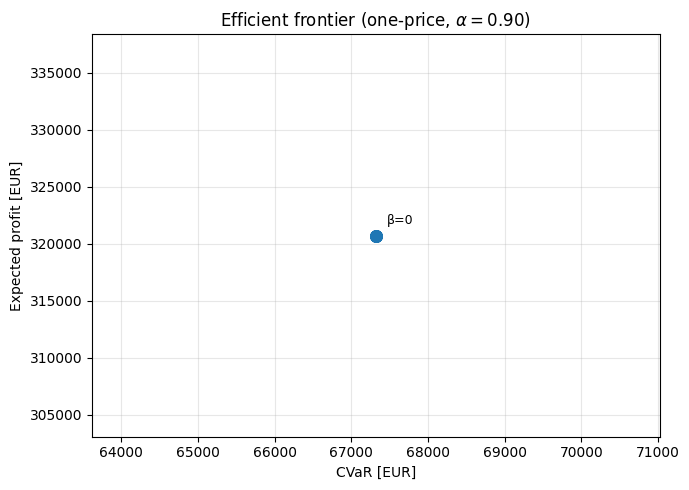

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp

P_nom = 500.0
alpha = 0.90
hours = list(range(24))
Omega = list(range(len(in_sample_idx)))
pi = 1.0 / len(Omega)

# Build arrays from in-sample joint scenarios
p_real = np.zeros((24, len(Omega)))
lam_DA = np.zeros((24, len(Omega)))
lam_bal = np.zeros((24, len(Omega)))
for w, (w_id, p_id, s_id) in enumerate(in_sample_idx):
    p_real[:, w] = wind_scenarios.xs(w_id, axis=1, level="scenario").iloc[:, 0].to_numpy()
    da = price_scenarios.xs(p_id, axis=1, level="scenario").iloc[:, 0].to_numpy()
    sys = system_scenarios.xs(s_id, axis=1, level="scenario").iloc[:, 0].to_numpy()
    lam_DA[:, w] = da
    lam_bal[:, w] = da * np.where(sys == 1, COEF_DEFICIT, COEF_EXCESS)

def scenario_profits(offers):
    return np.array([
        sum(
            lam_bal[t, w] * p_real[t, w] + (lam_DA[t, w] - lam_bal[t, w]) * offers[t]
            for t in hours
        )
        for w in Omega
    ])

def cvar_from_profits(profits, alpha):
    """Evaluate CVaR via Rockafellar–Uryasev (same definition as in the model)."""
    z = pulp.LpVariable("z")
    e = pulp.LpVariable.dicts("e", range(len(profits)), lowBound=0)
    pr = pulp.LpProblem("cvar_eval", pulp.LpMaximize)
    pr += z - (1 / (1 - alpha)) * pulp.lpSum((1 / len(profits)) * e[i] for i in range(len(profits)))
    for i, p in enumerate(profits):
        pr += e[i] >= z - float(p)
    pr.solve(pulp.PULP_CBC_CMD(msg=False))
    return pulp.value(pr.objective)

def solve_risk_averse(beta, alpha):
    prob = pulp.LpProblem("risk_averse", pulp.LpMaximize)
    p_DA = pulp.LpVariable.dicts("p_DA", hours, lowBound=0, upBound=P_nom)
    d_up = pulp.LpVariable.dicts("d_up", [(t, w) for t in hours for w in Omega], lowBound=0)
    d_dn = pulp.LpVariable.dicts("d_dn", [(t, w) for t in hours for w in Omega], lowBound=0)
    zeta = pulp.LpVariable("zeta")
    eta = pulp.LpVariable.dicts("eta", Omega, lowBound=0)

    profit = {
        w: pulp.lpSum(
            lam_DA[t, w] * p_DA[t]
            + lam_bal[t, w] * d_up[(t, w)]
            - lam_bal[t, w] * d_dn[(t, w)]
            for t in hours
        )
        for w in Omega
    }
    exp_profit = pulp.lpSum(pi * profit[w] for w in Omega)
    cvar = zeta - (1 / (1 - alpha)) * pulp.lpSum(pi * eta[w] for w in Omega)
    prob += exp_profit + beta * cvar

    for t in hours:
        for w in Omega:
            prob += p_real[t, w] - p_DA[t] == d_up[(t, w)] - d_dn[(t, w)]
    for w in Omega:
        prob += -profit[w] + zeta - eta[w] <= 0

    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    offers = np.array([pulp.value(p_DA[t]) for t in hours])
    profs = scenario_profits(offers)
    return {
        "beta": beta,
        "E_profit": float(profs.mean()),
        "CVaR": float(cvar_from_profits(profs, alpha)),
        "offers": offers,
    }

betas = [0, 0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 5, 8, 10, 15, 20, 50]
frontier = pd.DataFrame([solve_risk_averse(b, alpha) for b in betas])
print(frontier[["beta", "E_profit", "CVaR"]])

# --- 2D plot: expected profit vs CVaR ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(frontier["CVaR"], frontier["E_profit"], "o-", color="C0", markersize=8)
for _, row in frontier.drop_duplicates(subset=["E_profit", "CVaR"]).iterrows():
    ax.annotate(
        f"β={row['beta']:g}",
        (row["CVaR"], row["E_profit"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9,
    )
ax.set_xlabel("CVaR [EUR]")
ax.set_ylabel("Expected profit [EUR]")
ax.set_title(r"Efficient frontier (one-price, $\alpha=0.90$)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(opt_offers)
print("Expected profit:", pulp.value(exp_profit))
print("CVaR:", pulp.value(cvar))

9.0
0      97.142239
1      70.511013
2     200.643440
3     103.320830
4      64.440648
5      58.235823
6     131.045770
7      46.085254
8     371.940220
9     164.093350
10     47.029752
11     47.984088
12     68.349818
13     27.721662
14     62.589367
15     40.190343
16     37.356850
17    392.843790
18    142.753600
19     50.166599
20    128.799310
21    203.639270
22    131.601650
23    196.157080
Name: p_DA_MW, dtype: float64
Expected profit: 320714.4616421186
CVaR: 67319.9727685


With a 90% confidence level, the CVaR represents the average profit in the worst 10% of scenarios rather than the worst 5%. The risk-averse one-price optimization produces intermediate Day-Ahead offers across the 24 hours, instead of the bang-bang behavior observed in the risk-neutral case. This indicates that including CVaR changes the bidding strategy by giving greater importance to unfavorable profit outcomes and discouraging extreme Day-Ahead positions. The expected daily profit is approximately €320,714, while the CVaR is about €67,320, meaning that the average profit across the worst 10% of scenarios is substantially lower than the overall expected profit. This difference highlights a significant downside risk in the stochastic offering problem. By including CVaR in the objective function, the optimizer seeks a compromise between maximizing average profitability and improving performance under adverse wind and market realizations.

Two - Price scheme

     beta       E_profit          CVaR
0    0.00  267446.618119  42226.966990
1    0.10  267373.109795  43361.948015
2    0.25  267093.583734  45082.992275
3    0.50  266944.294126  45526.336382
4    0.75  266677.058200  45961.444030
5    1.00  266524.100592  46120.905643
6    1.50  266081.793639  46460.425070
7    2.00  265573.476846  46749.258590
8    3.00  264881.654670  47056.670945
9    5.00  264631.955932  47132.761025
10   8.00  264425.505452  47161.339710
11  10.00  264119.593066  47193.679480


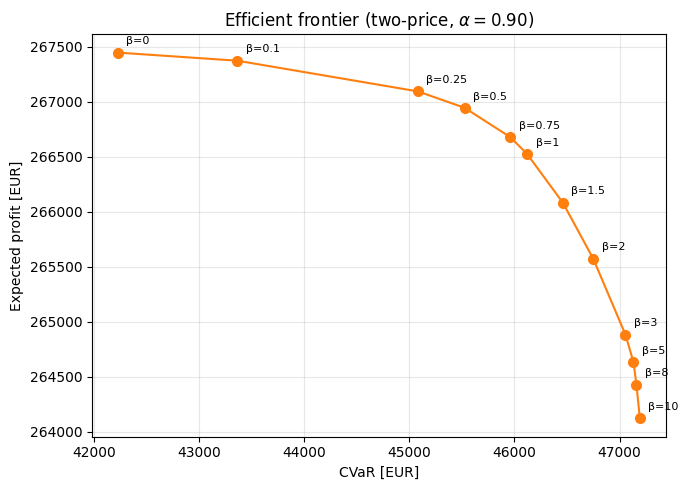

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp

P_nom = 500.0
alpha = 0.90
hours = list(range(24))
Omega = list(range(len(in_sample_idx)))
pi = 1.0 / len(Omega)

p_real = np.zeros((24, len(Omega)))
lam_DA = np.zeros((24, len(Omega)))
lam_up = np.zeros((24, len(Omega)))
lam_dn = np.zeros((24, len(Omega)))

for w, (w_id, p_id, s_id) in enumerate(in_sample_idx):
    p_real[:, w] = wind_scenarios.xs(w_id, axis=1, level="scenario").iloc[:, 0].to_numpy()
    da = price_scenarios.xs(p_id, axis=1, level="scenario").iloc[:, 0].to_numpy()
    sys = system_scenarios.xs(s_id, axis=1, level="scenario").iloc[:, 0].to_numpy()
    bal = da * np.where(sys == 1, COEF_DEFICIT, COEF_EXCESS)
    lam_DA[:, w] = da
    lam_up[:, w] = np.where(sys == 1, da, bal)  # deficit: surplus desired
    lam_dn[:, w] = np.where(sys == 1, bal, da)  # deficit: shortage undesired

def scenario_profits(offers):
    profs = np.zeros(len(Omega))
    for w in Omega:
        for t in hours:
            delta = p_real[t, w] - offers[t]
            profs[w] += (
                lam_DA[t, w] * offers[t]
                + lam_up[t, w] * max(delta, 0.0)
                - lam_dn[t, w] * max(-delta, 0.0)
            )
    return profs

def cvar_from_profits(profits, alpha):
    z = pulp.LpVariable("z")
    e = pulp.LpVariable.dicts("e", range(len(profits)), lowBound=0)
    pr = pulp.LpProblem("cvar_eval", pulp.LpMaximize)
    pr += z - (1 / (1 - alpha)) * pulp.lpSum((1 / len(profits)) * e[i] for i in range(len(profits)))
    for i, p in enumerate(profits):
        pr += e[i] >= z - float(p)
    pr.solve(pulp.PULP_CBC_CMD(msg=False))
    return pulp.value(pr.objective)

def solve_two_price_cvar(beta, alpha):
    prob = pulp.LpProblem("two_price_cvar", pulp.LpMaximize)
    p_DA = pulp.LpVariable.dicts("p_DA", hours, lowBound=0, upBound=P_nom)
    d_up = pulp.LpVariable.dicts("d_up", [(t, w) for t in hours for w in Omega], lowBound=0, upBound=P_nom)
    d_dn = pulp.LpVariable.dicts("d_dn", [(t, w) for t in hours for w in Omega], lowBound=0, upBound=P_nom)
    y = pulp.LpVariable.dicts("y", [(t, w) for t in hours for w in Omega], cat="Binary")
    zeta = pulp.LpVariable("zeta")
    eta = pulp.LpVariable.dicts("eta", Omega, lowBound=0)

    profit = {
        w: pulp.lpSum(
            lam_DA[t, w] * p_DA[t]
            + lam_up[t, w] * d_up[(t, w)]
            - lam_dn[t, w] * d_dn[(t, w)]
            for t in hours
        )
        for w in Omega
    }
    exp_profit = pulp.lpSum(pi * profit[w] for w in Omega)
    cvar = zeta - (1 / (1 - alpha)) * pulp.lpSum(pi * eta[w] for w in Omega)
    prob += exp_profit + beta * cvar

    for t in hours:
        for w in Omega:
            prob += p_real[t, w] - p_DA[t] == d_up[(t, w)] - d_dn[(t, w)]
            prob += d_up[(t, w)] <= P_nom * y[(t, w)]
            prob += d_dn[(t, w)] <= P_nom * (1 - y[(t, w)])
    for w in Omega:
        prob += -profit[w] + zeta - eta[w] <= 0

    try:
        status = prob.solve(pulp.GUROBI_CMD(msg=False, timeLimit=90))
    except Exception:
        status = prob.solve(pulp.PULP_CBC_CMD(msg=False, timeLimit=90))
    assert pulp.LpStatus[status] == "Optimal", pulp.LpStatus[status]

    offers = np.array([pulp.value(p_DA[t]) for t in hours])
    profs = scenario_profits(offers)
    return {
        "beta": beta,
        "E_profit": float(profs.mean()),
        "CVaR": float(cvar_from_profits(profs, alpha)),
        "offers": offers,
    }

betas = [0, 0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 5, 8, 10]
frontier = pd.DataFrame([solve_two_price_cvar(b, alpha) for b in betas])
print(frontier[["beta", "E_profit", "CVaR"]])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(frontier["CVaR"], frontier["E_profit"], "o-", color="C1", markersize=7)
for _, row in frontier.iterrows():
    ax.annotate(
        f"β={row['beta']:g}",
        (row["CVaR"], row["E_profit"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
    )
ax.set_xlabel("CVaR [EUR]")
ax.set_ylabel("Expected profit [EUR]")
ax.set_title(r"Efficient frontier (two-price, $\alpha=0.90$)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Under the two-price scheme, increasing the risk-aversion parameter \(\beta\) produces a clear trade-off between expected profit and downside-risk protection. In the risk-neutral case (\(\beta=0\)), the strategy achieves the highest expected profit, approximately €267,446, but also the lowest CVaR, around €42,227. As \(\beta\) increases, the optimizer progressively gives more importance to the worst 10% of profit scenarios, since \(\alpha=0.90\), and therefore adjusts the Day-Ahead offers to improve performance under unfavorable wind and market realizations. At \(\beta=10\), CVaR increases to approximately €47,194, an improvement of about 11.8%, while expected profit decreases to approximately €264,120, corresponding to a reduction of only about 1.2%. The efficient frontier therefore shows that a substantial improvement in downside protection can initially be achieved at a relatively limited cost in terms of average profitability. However, the curve also displays diminishing returns: for high values of \(\beta\), particularly beyond approximately \(\beta=3\), CVaR improves only marginally while expected profit continues to decrease. This suggests that very high levels of risk aversion provide limited additional protection and mainly result in sacrificing expected profit. Overall, the two-price scheme combined with CVaR allows the producer to move from a more profit-oriented strategy toward a more conservative offering strategy, explicitly balancing average profitability against protection from unfavorable outcomes.

## Offering strategy in ancillary service markets

It is considered a price-taking stochastic flexible load, which can either be a large energy consumer or an aggregator of small-scale loads, such as electric vehicles. This flexible load has a range of energy consumption from 0 kW to 600 kW. For simplicity, we focus on the FCR-D UP market in DK2 with hourly bids, where the flexible load seeks to sell its flexibility. The load can offer this service due to its ability to quickly adjust its consumption level. Importantly, we assume there is no minimum bid size requirement. To keep the analysis manageable, we consider a single hour for bidding with minute-level resolution for the flexible load’s consumption.

### Data Generation for Future Stochastic Load

Randomly generate 300 consumption load profiles, ensuring that for each profile, the load at every minute falls between 220 kW and 600 kW. Additionally, the change in consumption between two consecutive minutes must not exceed 35 kW. Out of these 300 profiles, use 100 for in-sample decision-making (i.e., reserve capacity bidding to the FCR-D UP market in kW), while the remaining 200 will be designated for out-of-sample analysis. Each in-sample profile will have an equal probability.

In [45]:
import numpy as np
import pandas as pd

n_profiles = 300
n_minutes = 24 * 60      # 1440; change if needed
P_min, P_max = 220.0, 600.0
dP_max = 35.0
rng = np.random.default_rng(42)  # reproducible; remove seed for fresh draws

load_profiles = np.empty((n_profiles, n_minutes))

for i in range(n_profiles):
    p = np.empty(n_minutes)
    p[0] = rng.uniform(P_min, P_max)
    for t in range(1, n_minutes):
        lo = max(P_min, p[t - 1] - dP_max)
        hi = min(P_max, p[t - 1] + dP_max)
        p[t] = rng.uniform(lo, hi)
    load_profiles[i] = p

# Optional: DataFrame with minute index
minutes = pd.RangeIndex(n_minutes, name="minute")
load_df = pd.DataFrame(
    load_profiles.T,
    index=minutes,
    columns=[f"profile_{i+1}" for i in range(n_profiles)],
)

# Checks
assert load_profiles.min() >= P_min and load_profiles.max() <= P_max
assert np.abs(np.diff(load_profiles, axis=1)).max() <= dP_max + 1e-9
print(load_df.shape)  # (1440, 300)

(1440, 300)


In [46]:
import numpy as np
import pandas as pd

# assumes load_profiles shape (n_profiles, n_minutes) = (300, 1440)
# or load_df with columns = profiles

n_profiles = load_profiles.shape[0]
assert n_profiles == 300

n_in = 100
n_out = 200

rng_split = np.random.default_rng(123)  # reproducible split
perm = rng_split.permutation(n_profiles)

in_sample_ids = perm[:n_in]
out_sample_ids = perm[n_in:]

load_in = load_profiles[in_sample_ids]    # (100, 1440)
load_out = load_profiles[out_sample_ids]  # (200, 1440)

# Equal probability for each in-sample profile
pi_in = np.full(n_in, 1.0 / n_in)         # π_ω = 1/100
assert np.isclose(pi_in.sum(), 1.0)

# Optional labeled DataFrames
minutes = pd.RangeIndex(load_profiles.shape[1], name="minute")
load_in_df = pd.DataFrame(
    load_in.T,
    index=minutes,
    columns=[f"ω{i+1}" for i in range(n_in)],
)
load_out_df = pd.DataFrame(
    load_out.T,
    index=minutes,
    columns=[f"ω{i+1}" for i in range(n_out)],
)
p_in = pd.Series(pi_in, index=load_in_df.columns, name="probability")

print(f"In-sample:  {load_in.shape[0]} profiles  (for FCR-D UP bidding)")
print(f"Out-of-sample: {load_out.shape[0]} profiles  (ex-post evaluation)")
print(f"π_ω = {pi_in[0]:.4f} for each in-sample profile")

In-sample:  100 profiles  (for FCR-D UP bidding)
Out-of-sample: 200 profiles  (ex-post evaluation)
π_ω = 0.0100 for each in-sample profile


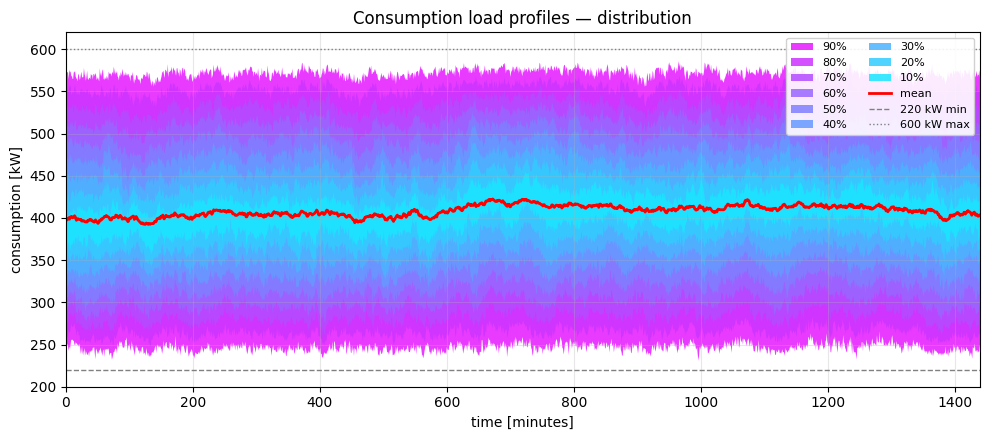

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# use all 300, or load_in / load_out
# load_profiles: shape (n_profiles, n_minutes)
scen = load_profiles.T                    # (1440, 300)
minutes = np.arange(scen.shape[0])

pred = scen.mean(axis=1)

intervals = list(range(10, 100, 10))       # 10% … 90% central bands
cmap = plt.cm.cool

fig, ax = plt.subplots(figsize=(10, 4.5))

for width in sorted(intervals, reverse=True):
    alpha = (100 - width) / 2             # 90% → 5–95; 10% → 45–55
    lo = np.percentile(scen, alpha, axis=1)
    hi = np.percentile(scen, 100 - alpha, axis=1)
    ax.fill_between(
        minutes, lo, hi,
        color=cmap(width / 100.0), alpha=0.85, linewidth=0,
        label=f"{width}%",
    )

ax.plot(minutes, pred, color="red", lw=2, label="mean")

ax.axhline(220, color="gray", ls="--", lw=1, label="220 kW min")
ax.axhline(600, color="gray", ls=":", lw=1, label="600 kW max")

ax.set_xlabel("time [minutes]")
ax.set_ylabel("consumption [kW]")
ax.set_xlim(minutes.min(), minutes.max())
ax.set_ylim(200, 620)
ax.set_title("Consumption load profiles — distribution")
ax.grid(True, alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper right", fontsize=8, framealpha=0.9, ncol=2)

plt.tight_layout()
plt.show()

### In-sample Decision Making: Offering Strategy Under the P90 Requirement

Given the P90 requirement of Energinet, determine the optimal reserve capacity bid (in kW) of the stochastic load in the FCR-D UP market for the given hour. Utilize both ALSO-X and CVaR techniques to solve this problem

ALSO-X

In [51]:
import numpy as np
import pulp

# --- requires: load_in shape (100, 1440), P_min = 220 ---
hour = 0                          # choose the hour (0..23)
epsilon = 0.1
M_big = 10_000.0
P_min = 220.0

m0, m1 = 60 * hour, 60 * (hour + 1)
F = (load_in[:, m0:m1] - P_min).T   # shape (60 minutes, 100 scenarios)
n_m, n_w = F.shape
q = epsilon * n_m * n_w             # 600
minutes, scenarios = range(n_m), range(n_w)

# ---- 1) LP relaxation (y continuous) ----
prob = pulp.LpProblem("also_x_lp", pulp.LpMaximize)
c = pulp.LpVariable("c", lowBound=0)
y = pulp.LpVariable.dicts(
    "y", [(m, w) for m in minutes for w in scenarios], lowBound=0, upBound=1
)
prob += c
for m in minutes:
    for w in scenarios:
        prob += c - float(F[m, w]) <= y[(m, w)] * M_big
prob += pulp.lpSum(y[(m, w)] for m in minutes for w in scenarios) <= q
prob.solve(pulp.PULP_CBC_CMD(msg=False))
c_val = pulp.value(c)
print(f"LP relaxation c = {c_val:.4f} kW  (often weak with large M)")

# ---- 2) ALSO-X iterative projection ----
tol, max_iter = 1e-6, 50
q_int = int(round(q))

for it in range(1, max_iter + 1):
    residual = c_val - F                         # >0 means violated if y=0
    flat = residual.ravel()
    idx = np.argpartition(flat, -q_int)[-q_int:] # q largest residuals
    y_bin = np.zeros_like(flat)
    y_bin[idx] = 1.0
    y_bin = y_bin.reshape(F.shape)

    c_new = float(F[y_bin < 0.5].min())
    print(f"ALSO-X iter {it}: c = {c_new:.4f} kW")
    if abs(c_new - c_val) <= tol:
        c_val = c_new
        break
    c_val = c_new

c_star = c_val
print(f"\nOptimal FCR-D UP bid c↑* = {c_star:.4f} kW")

# Optional check: (q+1)-th smallest F
F_sorted = np.sort(F.ravel())
print(f"Order statistic check: {F_sorted[q_int]:.4f} kW")

LP relaxation c = 1183.0420 kW  (often weak with large M)
ALSO-X iter 1: c = 47.7577 kW
ALSO-X iter 2: c = 47.7577 kW

Optimal FCR-D UP bid c↑* = 47.7577 kW
Order statistic check: 47.7577 kW


CVaR

In [52]:
import numpy as np
import pulp

# load_in: (100, 1440)
P_min = 220.0
epsilon = 0.10
hour = 0

m0, m1 = 60 * hour, 60 * (hour + 1)
F = np.maximum(load_in[:, m0:m1] - P_min, 0.0).T  # (60, 100)
n_m, n_w = F.shape
N = n_m * n_w

prob = pulp.LpProblem("FCR_D_Up_CVaR", pulp.LpMaximize)
c = pulp.LpVariable("c", lowBound=0)
beta = pulp.LpVariable("beta", upBound=0)  # β ≤ 0
zeta = pulp.LpVariable.dicts(
    "zeta", [(m, w) for m in range(n_m) for w in range(n_w)]
)

prob += c

for m in range(n_m):
    for w in range(n_w):
        # shortfall upper-bounded by ζ
        prob += c - float(F[m, w]) <= zeta[(m, w)]
        # β ≤ ζ_{m,ω}
        prob += beta <= zeta[(m, w)]

# (1/(|m||ω|)) Σ ζ ≤ (1-ε) β
prob += (
    pulp.lpSum(zeta[(m, w)] for m in range(n_m) for w in range(n_w)) / N
    <= (1 - epsilon) * beta
)

prob.solve(pulp.PULP_CBC_CMD(msg=False))
assert pulp.LpStatus[prob.status] == "Optimal"

c_star = pulp.value(c)
print(f"Optimal FCR-D UP bid (CVaR): {c_star:.4f} kW")
print(f"β* = {pulp.value(beta):.4f}")

Optimal FCR-D UP bid (CVaR): 26.7990 kW
β* = -20.9587


For the selected hour and the 100 in-sample load profiles, the ALSO-X procedure yields an optimal FCR-D Up bid of 47.76 kW, while the CVaR reformulation yields a lower bid of 26.80 kW. In the ALSO-X implementation, the initial LP relaxation with a large big-\(M\) constant is weak and returns an unrealistically high capacity of approximately 1183 kW. The subsequent projection step corrects this by allowing at most \(q=10\%\) of all minute-scenario pairs to violate the availability requirement and setting the bid according to the minimum flexibility among the remaining non-violating observations, which coincides with the order-statistic solution of 47.76 kW. Thus, ALSO-X primarily controls the frequency of reserve shortfalls across the sampled minute-scenario outcomes. The CVaR reformulation, instead, also accounts for the magnitude of shortfalls in the adverse tail of the same distribution. With \(\epsilon=0.1\) and an optimal threshold \(\beta\) of approximately \(-21\), the CVaR constraint provides a more conservative approximation of the same pooled chance constraint and therefore results in a lower offered capacity of 26.80 kW. Overall, both approaches use the same in-sample uncertainty and reliability parameter, but ALSO-X limits how often violations may occur, whereas the CVaR formulation additionally accounts for how severe those violations are, leading to a more cautious reserve bid.

### Verification of the P90 Requirement Using Out-of-Sample Analysis

Now using the 200 testing profiles, verify whether the P90 requirement is satisfied for both solution techniques used. This step does not require solving any optimization problem. Instead, compare the optimal reserve bid obtained with the actual power  consumption under each testing profile. For example, if the stochastic load bids 300 kW to the FCR-D UP market for a given hour, and its consumption at a certain minute within that hour is 270 kW, this would indicate a reserve shortfall of 30 kW for that minute.

In [53]:
import numpy as np

# requires load_out (200, 1440), P_min = 220
hour = 0
P_min = 220.0
m0, m1 = 60 * hour, 60 * (hour + 1)
P = load_out[:, m0:m1]                 # consumption [kW]
F = np.maximum(P - P_min, 0.0)         # FCR-D UP availability

bids = {"ALSO-X": 47.7577, "CVaR": 26.7990}

for name, c in bids.items():
    shortfall = np.maximum(c - F, 0.0)          # (n_out, 60)
    viol = shortfall > 1e-9

    frac_minute = 1.0 - viol.mean()             # over all minutes × profiles
    frac_joint = (~viol.any(axis=1)).mean()     # whole hour OK

    print(f"\n{name}: c = {c:.4f} kW")
    print(f"  Minute-level availability: {100*frac_minute:.2f}%  "
          f"(P90? {'YES' if frac_minute >= 0.9 else 'NO'})")
    print(f"  Joint hourly availability: {100*frac_joint:.2f}%  "
          f"(P90? {'YES' if frac_joint >= 0.9 else 'NO'})")
    print(f"  Mean shortfall: {shortfall.mean():.4f} kW | "
          f"Max shortfall: {shortfall.max():.4f} kW")


ALSO-X: c = 47.7577 kW
  Minute-level availability: 86.01%  (P90? NO)
  Joint hourly availability: 50.50%  (P90? NO)
  Mean shortfall: 2.9216 kW | Max shortfall: 47.7258 kW

CVaR: c = 26.7990 kW
  Minute-level availability: 93.60%  (P90? YES)
  Joint hourly availability: 55.50%  (P90? NO)
  Mean shortfall: 0.7726 kW | Max shortfall: 26.7671 kW


On the 200 out-of-sample profiles, neither method fully guarantees the P90 requirement in every sense, but CVaR is clearly more reliable. The ALSO-X bid of 47.76 kW is available in only 86.0 percent of minute-profile checks and in just 50.5 percent of full hours, so it misses P90 both minute-wise and jointly; when shortfalls occur they can be large (mean shortfall 2.92 kW, max about 47.7 kW). The smaller CVaR bid of 26.80 kW reaches 93.6 percent minute-level availability and therefore meets a minute-based P90 target, with much milder shortages (mean 0.77 kW, max about 26.8 kW), but it still covers the whole hour in only 55.5 percent of testing profiles, so it fails a strict joint hourly P90. In simple terms, ALSO-X sells more capacity in-sample but is too aggressive out-of-sample, while CVaR sells less, keeps shortfalls smaller, and is the only one that passes the minute-level P90 check—yet both struggle when availability is required in every minute of the hour for most unseen profiles.

### Energinet Perspective

Take the perspective of Energinet and investigate how varying the P90 requirement (e.g., by adjusting the allowed frequency of reserve shortfall between 80% and 100%) impacts the optimal reserve bid (in-sample analysis using ALSO-X) and the expected reserve shortfall (out-of-sample analysis). Analyze whether there is an observable trade-off between these two factors as the P90 requirement is relaxed or tightened.

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# requires: load_in (100, 1440), load_out (200, 1440), P_min = 220.0
hour = 0
m0, m1 = 60 * hour, 60 * (hour + 1)

F_in = np.maximum(load_in[:, m0:m1] - P_min, 0.0).T   # (60, 100)
F_out = np.maximum(load_out[:, m0:m1] - P_min, 0.0)    # (200, 60)
n_m, n_w = F_in.shape
F_sorted = np.sort(F_in.ravel())

targets = np.round(np.arange(0.80, 1.001, 0.02), 2)  # 80% ... 100%
rows = []

for avail in targets:
    eps = 1.0 - avail
    q = int(round(eps * n_m * n_w))
    c = float(F_sorted[q]) if q < len(F_sorted) else float(F_sorted[-1])

    shortfall = np.maximum(c - F_out, 0.0)
    viol = shortfall > 1e-9

    minute_avail = 1.0 - viol.mean()
    joint_avail = (~viol.any(axis=1)).mean()

    rows.append({
        "availability_req": avail,
        "epsilon": eps,
        "q": q,
        "c_kW": c,
        "E_shortfall_kW": shortfall.mean(),
        "minute_avail_OOS": minute_avail,
        "joint_avail_OOS": joint_avail,
        "max_shortfall_kW": shortfall.max(),
    })

df = pd.DataFrame(rows)

print(
    df.assign(
        **{
            "Avail. req.": (100 * df["availability_req"]).map(lambda x: f"{x:.0f}%"),
            "Bid [kW]": df["c_kW"].round(2),
            "E[shortfall] [kW]": df["E_shortfall_kW"].round(3),
            "Minute-level avail. OOS": (100 * df["minute_avail_OOS"]).map(lambda x: f"{x:.2f}%"),
            "Joint hourly avail. OOS": (100 * df["joint_avail_OOS"]).map(lambda x: f"{x:.2f}%"),
        }
    )[
        [
            "Avail. req.",
            "Bid [kW]",
            "E[shortfall] [kW]",
            "Minute-level avail. OOS",
            "Joint hourly avail. OOS",
        ]
    ].to_string(index=False)
)

Avail. req.  Bid [kW]  E[shortfall] [kW] Minute-level avail. OOS Joint hourly avail. OOS
        80%     75.86              8.215                  76.57%                  43.50%
        82%     70.95              7.103                  78.10%                  45.00%
        84%     64.88              5.832                  80.00%                  46.50%
        86%     59.95              4.892                  81.69%                  49.00%
        88%     54.06              3.872                  83.87%                  50.00%
        90%     47.76              2.922                  86.01%                  50.50%
        92%     38.59              1.786                  89.18%                  51.50%
        94%     32.03              1.156                  91.68%                  52.50%
        96%     25.41              0.687                  94.06%                  55.50%
        98%     13.47              0.179                  97.31%                  58.00%
       100%      0.14

Tightening the availability requirement from 80% to 100% lowers the ALSO-X bid and the out-of-sample expected shortfall: about 76 kW and 8.2 kW shortfall at 80%, about 48 kW and 2.9 kW at P90, and nearly zero bid/shortfall at 100%. Minute-level reliability improves with a stricter standard and only clearly exceeds 90% out of sample from about 94% upward, while joint hourly availability stays much weaker (roughly 44–58%) until the extreme 100% case. So Energinet faces a trade-off: a looser rule buys more FCR-D UP but accepts more shortages; a tighter rule improves delivery but shrinks usable capacity, with full-hour availability remaining the harder target. Expected shortfall represents the average size of the capacity gap (including zeros).